In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("traffic_data.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [5]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [14]:
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.date

In [15]:
hourly_avg = df.groupby("Hour")["Vehicle_Count"].mean()

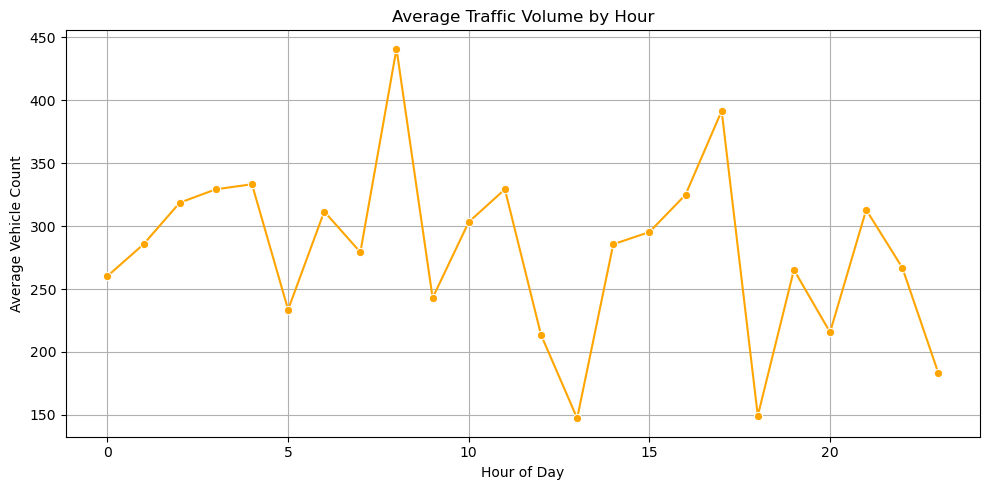

In [16]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker='o', color='orange')
plt.title("Average Traffic Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
threshold = hourly_avg.mean() + hourly_avg.std()
peak_hours = hourly_avg[hourly_avg > threshold]

print(f"\nPeak Traffic Hours (Avg Vehicle Count > {threshold:.2f}):")
print(peak_hours)


Peak Traffic Hours (Avg Vehicle Count > 349.02):
Hour
8     441.000000
17    391.666667
Name: Vehicle_Count, dtype: float64


In [20]:
low_traffic_hours = hourly_avg[hourly_avg < hourly_avg.mean()]
print(f"\nSuggested Maintenance Windows (Low Traffic):")
print(low_traffic_hours.sort_values())


Suggested Maintenance Windows (Low Traffic):
Hour
13    147.333333
18    149.333333
23    183.000000
12    213.666667
20    215.666667
5     233.666667
9     243.000000
0     260.333333
19    265.333333
22    267.000000
7     279.333333
Name: Vehicle_Count, dtype: float64


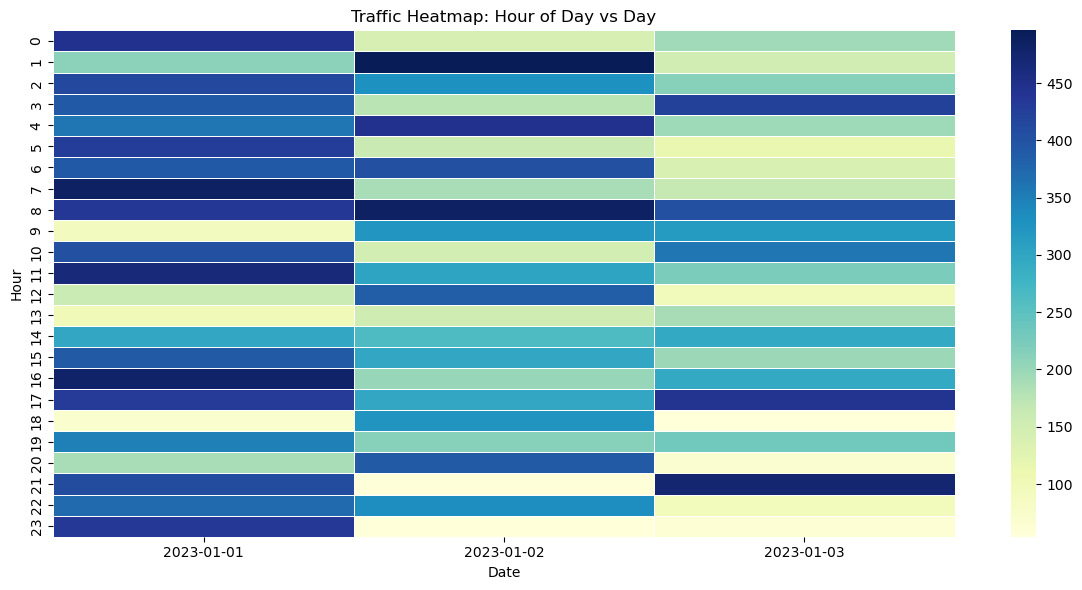

In [21]:
pivot = df.pivot_table(index=df['Hour'], columns=df['Day'], values='Vehicle_Count', aggfunc='mean')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='YlGnBu', linewidths=0.5)
plt.title("Traffic Heatmap: Hour of Day vs Day")
plt.xlabel("Date")
plt.ylabel("Hour")
plt.tight_layout()
plt.show()